In [1]:
# ============================================================
# PM2.5 BENCHMARK DATASET CONSTRUCTION
# Feature engineering → chronological splitting →
# training-only scaling → 7-day sliding windows
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder, MinMaxScaler


# ============================================================
# 1. Configuration
# ============================================================

INPUT_FILE = "/Users/mac/Desktop/DataVisualization/New_PM/weather_pm_ghg_final_clean.xlsx"
OUTPUT_DIR = "prepared_benchmark_data"

SEQ_LEN = 7
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

STATIONS = ["JER00005", "NAB00003"]

os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# 2. Load the integrated and cleaned dataset
# ============================================================

df = pd.read_excel(INPUT_FILE)

# Remove accidental spaces from column names
df.columns = df.columns.astype(str).str.strip()

print("Original shape:", df.shape)
print("Original columns:")
print(df.columns.tolist())


Original shape: (366, 16)
Original columns:
['Station', 'Date', 'Temperature', 'Sunshine', 'RH', 'PRESS', 'Rainfall', 'Wind', 'Month', 'Year', 'Day', 'DayOfWeek', 'PM2.5', 'CO2', 'CH4', 'N2O']


In [2]:
# ============================================================
# 3. Standardize column names
# ============================================================
# This allows the script to work with names used in your files.

column_aliases = {
    "Temp": "Temperature",
    "RH": "RH",
    "PRESS": "PRESS",
    "Rain": "Rainfall",
    "Wind": "Wind",
    "wind_speed": "Wind",
    "SUNSHINE": "Sunshine",
    "PM25": "PM2.5",
    "PM2_5": "PM2.5"
}

df = df.rename(
    columns={
        old: new
        for old, new in column_aliases.items()
        if old in df.columns and new not in df.columns
    }
)


# ============================================================
# 4. Validate required columns
# ============================================================

required_columns = [
    "Station",
    "Date",
    "Temperature",
    "Sunshine",
    "RH",
    "PRESS",
    "Rainfall",
    "Wind",
    "PM2.5"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise KeyError(
        "The following required columns are missing:\n"
        f"{missing_columns}\n\n"
        f"Available columns are:\n{df.columns.tolist()}"
    )


# ============================================================
# 5. Basic consistency checks
# ============================================================

df["Station"] = df["Station"].astype(str).str.strip()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Retain only the two benchmark stations
df = df[df["Station"].isin(STATIONS)].copy()

# Convert measurement columns to numeric
measurement_columns = [
    "Temperature",
    "Sunshine",
    "RH",
    "PRESS",
    "Rainfall",
    "Wind",
    "PM2.5"
]

for column in measurement_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

# Remove records without a valid station or date
df = df.dropna(subset=["Station", "Date"])

# Remove exact station-date duplicates
df = df.drop_duplicates(
    subset=["Station", "Date"],
    keep="first"
)

# Sort chronologically within each station
df = (
    df.sort_values(["Station", "Date"])
      .reset_index(drop=True)
)

print("\nSelected stations:", df["Station"].unique())
print("Shape after filtering:", df.shape)
print("Duplicate station-date records:",
      df.duplicated(["Station", "Date"]).sum())




Selected stations: <StringArray>
['JER00005', 'NAB00003']
Length: 2, dtype: str
Shape after filtering: (366, 16)
Duplicate station-date records: 0


In [3]:
# ============================================================
# 6. Feature engineering
# ============================================================
# Calendar variables are extracted from the date.

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

# Encode the station identifier
station_encoder = LabelEncoder()
df["Station_enc"] = station_encoder.fit_transform(df["Station"])

station_mapping = dict(
    zip(
        station_encoder.classes_,
        station_encoder.transform(station_encoder.classes_)
    )
)

print("\nStation encoding:")
print(station_mapping)

# Save station encoding
station_mapping_df = pd.DataFrame({
    "Station": station_encoder.classes_,
    "Station_enc": station_encoder.transform(
        station_encoder.classes_
    )
})

station_mapping_df.to_csv(
    os.path.join(OUTPUT_DIR, "station_encoding.csv"),
    index=False
)


# ============================================================
# 7. Define input features and target
# ============================================================

features = [
    "PM2.5",          # Historical target observations
    "Temperature",
    "Sunshine",
    "RH",
    "PRESS",
    "Rainfall",
    "Wind",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "Station_enc"
]

target = "PM2.5"

print("\nInput features:")
for feature in features:
    print("-", feature)

print("\nTarget:", target)


# ============================================================
# 8. Check missing values before splitting
# ============================================================

missing_summary = df[
    ["Station", "Date"] + features
].isna().sum()

print("\nMissing values before splitting:")
print(missing_summary)

if df[features].isna().any().any():
    problematic = df[features].isna().sum()
    problematic = problematic[problematic > 0]

    raise ValueError(
        "Missing values remain in the modeling dataset.\n"
        "Handle them before running the benchmark pipeline:\n"
        f"{problematic}"
    )




Station encoding:
{'JER00005': np.int64(0), 'NAB00003': np.int64(1)}

Input features:
- PM2.5
- Temperature
- Sunshine
- RH
- PRESS
- Rainfall
- Wind
- Year
- Month
- Day
- DayOfWeek
- Station_enc

Target: PM2.5

Missing values before splitting:
Station        0
Date           0
PM2.5          0
Temperature    0
Sunshine       0
RH             0
PRESS          0
Rainfall       0
Wind           0
Year           0
Month          0
Day            0
DayOfWeek      0
Station_enc    0
dtype: int64


In [4]:
# ============================================================
# 9. Station-wise chronological splitting
# ============================================================
# Each station is split independently:
# earliest 70% → training
# next 15%     → validation
# latest 15%   → testing

train_parts = []
val_parts = []
test_parts = []
split_information = []

for station, station_df in df.groupby("Station", sort=False):

    station_df = (
        station_df.sort_values("Date")
                  .reset_index(drop=True)
    )

    n_records = len(station_df)

    train_end = int(n_records * TRAIN_RATIO)
    val_end = int(n_records * (TRAIN_RATIO + VAL_RATIO))

    train_station = station_df.iloc[:train_end].copy()
    val_station = station_df.iloc[train_end:val_end].copy()
    test_station = station_df.iloc[val_end:].copy()

    # Each subset must have enough rows for a 7-day sequence
    for split_name, split_df in {
        "Training": train_station,
        "Validation": val_station,
        "Test": test_station
    }.items():
        if len(split_df) <= SEQ_LEN:
            raise ValueError(
                f"{station} has only {len(split_df)} records in the "
                f"{split_name} set. More than {SEQ_LEN} records are "
                "required to create sequences."
            )

    train_parts.append(train_station)
    val_parts.append(val_station)
    test_parts.append(test_station)

    split_information.append({
        "Station": station,
        "Total records": n_records,
        "Training records": len(train_station),
        "Training start": train_station["Date"].min(),
        "Training end": train_station["Date"].max(),
        "Validation records": len(val_station),
        "Validation start": val_station["Date"].min(),
        "Validation end": val_station["Date"].max(),
        "Test records": len(test_station),
        "Test start": test_station["Date"].min(),
        "Test end": test_station["Date"].max()
    })


train_df = pd.concat(train_parts, ignore_index=True)
val_df = pd.concat(val_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

split_summary = pd.DataFrame(split_information)

print("\nChronological split summary:")
print(split_summary.to_string(index=False))

split_summary.to_excel(
    os.path.join(
        OUTPUT_DIR,
        "chronological_split_summary.xlsx"
    ),
    index=False
)


# ============================================================
# 10. Verify chronological separation
# ============================================================

for station in df["Station"].unique():

    station_train = train_df[
        train_df["Station"] == station
    ]

    station_val = val_df[
        val_df["Station"] == station
    ]

    station_test = test_df[
        test_df["Station"] == station
    ]

    train_max = station_train["Date"].max()
    val_min = station_val["Date"].min()
    val_max = station_val["Date"].max()
    test_min = station_test["Date"].min()

    if not (train_max < val_min and val_max < test_min):
        raise ValueError(
            f"Chronological order failed for station {station}."
        )

print("\nChronological boundaries verified successfully.")




Chronological split summary:
 Station  Total records  Training records Training start Training end  Validation records Validation start Validation end  Test records Test start   Test end
JER00005            189               132     2024-09-07   2025-03-09                  28       2025-03-10     2025-04-06            29 2025-04-07 2025-05-05
NAB00003            177               123     2024-06-13   2025-03-12                  27       2025-03-13     2025-04-08            27 2025-04-09 2025-05-05

Chronological boundaries verified successfully.


In [5]:
# ============================================================
# 11. Training-only Min–Max scaling
# ============================================================
# The scalers are fitted ONLY using training observations.

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaler.fit(train_df[features])
y_scaler.fit(train_df[[target]])

train_scaled = train_df.copy()
val_scaled = val_df.copy()
test_scaled = test_df.copy()

# Transform predictors
train_scaled[features] = x_scaler.transform(
    train_df[features]
)

val_scaled[features] = x_scaler.transform(
    val_df[features]
)

test_scaled[features] = x_scaler.transform(
    test_df[features]
)

# Transform target
# PM2.5 is also present among the historical input features.
train_scaled[[target]] = y_scaler.transform(
    train_df[[target]]
)

val_scaled[[target]] = y_scaler.transform(
    val_df[[target]]
)

test_scaled[[target]] = y_scaler.transform(
    test_df[[target]]
)

# Save fitted preprocessing objects
joblib.dump(
    x_scaler,
    os.path.join(OUTPUT_DIR, "x_scaler.pkl")
)

joblib.dump(
    y_scaler,
    os.path.join(OUTPUT_DIR, "y_scaler.pkl")
)

joblib.dump(
    station_encoder,
    os.path.join(OUTPUT_DIR, "station_encoder.pkl")
)

print("\nScalers fitted using training data only.")



Scalers fitted using training data only.


In [6]:
# ============================================================
# 12. Seven-day sliding-window function
# ============================================================

def create_sequences(
    data: pd.DataFrame,
    feature_columns: list[str],
    target_column: str,
    sequence_length: int = 7
):
    """
    Create station-wise time-series sequences.

    Input:
        Previous sequence_length days of all features.

    Target:
        PM2.5 concentration on the following day.

    Returns:
        X          : 3D input array
        y          : target array
        stations   : station for each target
        dates      : target date for each sequence
        last_pm25  : latest historical PM2.5 value for persistence
    """

    X = []
    y = []
    station_labels = []
    target_dates = []
    persistence_values = []

    for station, station_data in data.groupby(
        "Station",
        sort=False
    ):

        station_data = (
            station_data.sort_values("Date")
                        .reset_index(drop=True)
        )

        feature_values = station_data[
            feature_columns
        ].to_numpy(dtype=np.float32)

        target_values = station_data[
            target_column
        ].to_numpy(dtype=np.float32)

        dates = station_data["Date"].to_numpy()

        # Location of historical PM2.5 in feature list
        pm25_index = feature_columns.index("PM2.5")

        for start in range(
            len(station_data) - sequence_length
        ):
            end = start + sequence_length
            target_index = end

            sequence = feature_values[start:end]

            X.append(sequence)
            y.append(target_values[target_index])

            station_labels.append(station)
            target_dates.append(dates[target_index])

            # Persistence forecast = PM2.5 at day t
            persistence_values.append(
                sequence[-1, pm25_index]
            )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32).reshape(-1, 1),
        np.asarray(station_labels),
        np.asarray(target_dates),
        np.asarray(
            persistence_values,
            dtype=np.float32
        ).reshape(-1, 1)
    )

In [7]:
# ============================================================
# 13. Generate sequences independently in each subset
# ============================================================

(
    X_train,
    y_train,
    train_stations,
    train_dates,
    persistence_train
) = create_sequences(
    train_scaled,
    features,
    target,
    SEQ_LEN
)

(
    X_val,
    y_val,
    val_stations,
    val_dates,
    persistence_val
) = create_sequences(
    val_scaled,
    features,
    target,
    SEQ_LEN
)

(
    X_test,
    y_test,
    test_stations,
    test_dates,
    persistence_test
) = create_sequences(
    test_scaled,
    features,
    target,
    SEQ_LEN
)


print("\nSequence dataset shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


# ============================================================
# 14. Verify sequence dimensions
# ============================================================

expected_feature_count = len(features)

assert X_train.shape[1] == SEQ_LEN
assert X_val.shape[1] == SEQ_LEN
assert X_test.shape[1] == SEQ_LEN

assert X_train.shape[2] == expected_feature_count
assert X_val.shape[2] == expected_feature_count
assert X_test.shape[2] == expected_feature_count

print(
    f"\nVerified input format: "
    f"(samples, {SEQ_LEN} days, "
    f"{expected_feature_count} features)"
)


Sequence dataset shapes:
X_train: (241, 7, 12)
y_train: (241, 1)
X_val: (41, 7, 12)
y_val: (41, 1)
X_test: (42, 7, 12)
y_test: (42, 1)

Verified input format: (samples, 7 days, 12 features)


In [8]:
# ============================================================
# 15. Create flattened inputs for classical ML models
# ============================================================
# Use these arrays for:
# Linear Regression, Random Forest, XGBoost and SVR.

X_train_flat = X_train.reshape(
    X_train.shape[0],
    -1
)

X_val_flat = X_val.reshape(
    X_val.shape[0],
    -1
)

X_test_flat = X_test.reshape(
    X_test.shape[0],
    -1
)

print("\nFlattened shapes for machine learning:")
print("X_train_flat:", X_train_flat.shape)
print("X_val_flat:", X_val_flat.shape)
print("X_test_flat:", X_test_flat.shape)



Flattened shapes for machine learning:
X_train_flat: (241, 84)
X_val_flat: (41, 84)
X_test_flat: (42, 84)


In [9]:
# ============================================================
# 16. Convert targets and persistence predictions
#     back to original PM2.5 units
# ============================================================

y_train_original = y_scaler.inverse_transform(y_train)
y_val_original = y_scaler.inverse_transform(y_val)
y_test_original = y_scaler.inverse_transform(y_test)

persistence_train_original = y_scaler.inverse_transform(
    persistence_train
)

persistence_val_original = y_scaler.inverse_transform(
    persistence_val
)

persistence_test_original = y_scaler.inverse_transform(
    persistence_test
)


# ============================================================
# 17. Save processed row-level datasets
# ============================================================

train_df.to_excel(
    os.path.join(OUTPUT_DIR, "train_unscaled.xlsx"),
    index=False
)

val_df.to_excel(
    os.path.join(OUTPUT_DIR, "validation_unscaled.xlsx"),
    index=False
)

test_df.to_excel(
    os.path.join(OUTPUT_DIR, "test_unscaled.xlsx"),
    index=False
)


# ============================================================
# 18. Save sequence arrays
# ============================================================

np.savez_compressed(
    os.path.join(
        OUTPUT_DIR,
        "benchmark_sequences.npz"
    ),

    X_train=X_train,
    y_train=y_train,

    X_val=X_val,
    y_val=y_val,

    X_test=X_test,
    y_test=y_test,

    X_train_flat=X_train_flat,
    X_val_flat=X_val_flat,
    X_test_flat=X_test_flat,

    train_stations=train_stations,
    val_stations=val_stations,
    test_stations=test_stations,

    train_dates=train_dates,
    val_dates=val_dates,
    test_dates=test_dates,

    persistence_train=persistence_train,
    persistence_val=persistence_val,
    persistence_test=persistence_test
)


# ============================================================
# 19. Save test-set metadata for figures and evaluation
# ============================================================

test_metadata = pd.DataFrame({
    "Station": test_stations,
    "Target_Date": pd.to_datetime(test_dates),
    "Observed_PM2.5": y_test_original.ravel(),
    "Persistence_PM2.5": (
        persistence_test_original.ravel()
    )
})

test_metadata.to_excel(
    os.path.join(
        OUTPUT_DIR,
        "test_sequence_metadata.xlsx"
    ),
    index=False
)


# ============================================================
# 20. Final summary
# ============================================================

print("\n" + "=" * 60)
print("DATASET CONSTRUCTION COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nDeep-learning inputs:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nMachine-learning inputs:")
print("Train:", X_train_flat.shape)
print("Validation:", X_val_flat.shape)
print("Test:", X_test_flat.shape)

print("\nFiles saved in:")
print(os.path.abspath(OUTPUT_DIR))


DATASET CONSTRUCTION COMPLETED SUCCESSFULLY

Deep-learning inputs:
Train: (241, 7, 12)
Validation: (41, 7, 12)
Test: (42, 7, 12)

Machine-learning inputs:
Train: (241, 84)
Validation: (41, 84)
Test: (42, 84)

Files saved in:
/Users/mac/prepared_benchmark_data


In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# ==========================================
# Persistence prediction
# ==========================================

y_true = y_test_original.ravel()

y_pred = persistence_test_original.ravel()

# ==========================================
# Evaluation
# ==========================================

mae = mean_absolute_error(y_true, y_pred)

mse = mean_squared_error(y_true, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_true, y_pred)

print("="*50)
print("Persistence Model")
print("="*50)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

Persistence Model
MAE : 6.4000
MSE : 85.2581
RMSE: 9.2335
R²  : 0.0027


In [11]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(X_train_flat.shape)
print(X_test_flat.shape)

print(y_train_original.min(), y_train_original.max())
print(y_test_original.min(), y_test_original.max())

(241, 7, 12)
(41, 7, 12)
(42, 7, 12)
(241, 84)
(42, 84)
4.5 205.0
5.2 46.0


In [12]:
# ============================================================
# Linear Regression Benchmark
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# Train Linear Regression
# ============================================================

lr_model = LinearRegression()

lr_model.fit(
    X_train_flat,
    y_train.ravel()
)

# ============================================================
# Predictions (scaled)
# ============================================================

y_train_pred = lr_model.predict(X_train_flat)
y_val_pred = lr_model.predict(X_val_flat)
y_test_pred = lr_model.predict(X_test_flat)

# ============================================================
# Convert predictions back to original PM2.5 units
# ============================================================

y_train_pred_original = y_scaler.inverse_transform(
    y_train_pred.reshape(-1,1)
)

y_val_pred_original = y_scaler.inverse_transform(
    y_val_pred.reshape(-1,1)
)

y_test_pred_original = y_scaler.inverse_transform(
    y_test_pred.reshape(-1,1)
)

# ============================================================
# Evaluation on ORIGINAL values
# ============================================================

y_true = y_test_original.ravel()
y_pred = y_test_pred_original.ravel()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("="*60)
print("Linear Regression Results")
print("="*60)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# ============================================================
# Save predictions
# ============================================================

results_lr = pd.DataFrame({
    "Station": test_stations,
    "Date": pd.to_datetime(test_dates),
    "Observed_PM2.5": y_true,
    "Predicted_PM2.5": y_pred,
    "Residual": y_true - y_pred
})

results_lr.to_excel(
    "Linear_Regression_Predictions.xlsx",
    index=False
)

print("\nPredictions saved to:")
print("Linear_Regression_Predictions.xlsx")

Linear Regression Results
MAE : 9.3980
MSE : 171.2834
RMSE: 13.0875
R²  : -1.0035

Predictions saved to:
Linear_Regression_Predictions.xlsx


In [13]:
print("Observed:")
print(y_true[:10])

print("\nPredicted:")
print(y_pred[:10])

Observed:
[ 5.2        6.9999995  9.3        8.5        7.7999997 10.3
  9.        12.700001  26.4       46.       ]

Predicted:
[ 3.8253932  8.868799   9.268055   8.606175  17.839813  -3.8341353
 11.477757  14.226061  16.67066   27.0332   ]


In [14]:
print("Observed range:")
print(y_true.min(), y_true.max())

print("Predicted range:")
print(y_pred.min(), y_pred.max())

Observed range:
5.2 46.0
Predicted range:
-3.8341353 54.877434


In [15]:
# Prevent physically impossible predictions
y_test_pred_original = np.clip(
    y_test_pred_original,
    0,
    None
)

In [16]:
# ============================================================
# Random Forest Benchmark
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. Build and train the model
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_split=8,
    min_samples_leaf=4,
    random_state=42,
   # n_jobs=-1
)

rf_model.fit(
    X_train_flat,
    y_train.ravel()
)

# ============================================================
# 2. Predict scaled PM2.5 values
# ============================================================

y_train_pred_scaled = rf_model.predict(X_train_flat)
y_val_pred_scaled = rf_model.predict(X_val_flat)
y_test_pred_scaled = rf_model.predict(X_test_flat)

# ============================================================
# 3. Convert predictions to original PM2.5 units
# ============================================================

y_train_pred_original = y_scaler.inverse_transform(
    y_train_pred_scaled.reshape(-1, 1)
)

y_val_pred_original = y_scaler.inverse_transform(
    y_val_pred_scaled.reshape(-1, 1)
)

y_test_pred_original = y_scaler.inverse_transform(
    y_test_pred_scaled.reshape(-1, 1)
)

# Random Forest predictions should normally be non-negative,
# but this ensures physically valid PM2.5 concentrations.
y_test_pred_original = np.clip(
    y_test_pred_original,
    0,
    None
)

# ============================================================
# 4. Evaluate on the original PM2.5 scale
# ============================================================

y_true = y_test_original.ravel()
y_pred = y_test_pred_original.ravel()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("=" * 60)
print("Random Forest Results")
print("=" * 60)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# ============================================================
# 5. Save test predictions
# ============================================================

rf_predictions = pd.DataFrame({
    "Station": test_stations,
    "Date": pd.to_datetime(test_dates),
    "Observed_PM2.5": y_true,
    "Predicted_PM2.5": y_pred,
    "Residual": y_true - y_pred
})

rf_predictions.to_excel(
    "Random_Forest_Predictions.xlsx",
    index=False
)

print("\nPredictions saved as:")
print("Random_Forest_Predictions.xlsx")

# ============================================================
# 6. Optional feature importance
# ============================================================

feature_names_flat = [
    f"{feature}_day_{day + 1}"
    for day in range(7)
    for feature in features
]

feature_importance = pd.DataFrame({
    "Feature": feature_names_flat,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance.to_excel(
    "Random_Forest_Feature_Importance.xlsx",
    index=False
)

print("\nFeature importance saved as:")
print("Random_Forest_Feature_Importance.xlsx")

print("\nTop 15 features:")
print(feature_importance.head(15))

Random Forest Results
MAE : 6.8398
MSE : 90.7600
RMSE: 9.5268
R²  : -0.0616

Predictions saved as:
Random_Forest_Predictions.xlsx

Feature importance saved as:
Random_Forest_Feature_Importance.xlsx

Top 15 features:
              Feature  Importance
72        PM2.5_day_7    0.311427
78         Wind_day_7    0.138301
77     Rainfall_day_7    0.127282
29     Rainfall_day_3    0.039252
60        PM2.5_day_6    0.028666
81          Day_day_7    0.023656
66         Wind_day_6    0.021613
39           RH_day_4    0.019682
57          Day_day_5    0.014105
24        PM2.5_day_3    0.012220
73  Temperature_day_7    0.012050
18         Wind_day_2    0.010881
1   Temperature_day_1    0.010420
0         PM2.5_day_1    0.010375
69          Day_day_6    0.009993


In [17]:
print(train_df["Station"].value_counts())
print(val_df["Station"].value_counts())
print(test_df["Station"].value_counts())

Station
JER00005    132
NAB00003    123
Name: count, dtype: int64
Station
JER00005    28
NAB00003    27
Name: count, dtype: int64
Station
JER00005    29
NAB00003    27
Name: count, dtype: int64


In [18]:
print(train_df["Date"].min(), train_df["Date"].max())
print(val_df["Date"].min(), val_df["Date"].max())
print(test_df["Date"].min(), test_df["Date"].max())

2024-06-13 00:00:00 2025-03-12 00:00:00
2025-03-10 00:00:00 2025-04-08 00:00:00
2025-04-07 00:00:00 2025-05-05 00:00:00


In [19]:
print(train_df["PM2.5"].describe())
print(test_df["PM2.5"].describe())

count    255.000000
mean      17.165490
std       14.722314
min        4.500000
25%       10.850000
50%       15.300000
75%       19.950000
max      205.000000
Name: PM2.5, dtype: float64
count    56.000000
mean     13.621429
std       9.138405
min       5.200000
25%       7.975000
50%      10.000000
75%      14.675000
max      46.000000
Name: PM2.5, dtype: float64


In [20]:
print(train_df[train_df["PM2.5"] > 100][["Date","Station","PM2.5"]])

          Date   Station  PM2.5
235 2025-02-21  NAB00003  205.0
236 2025-02-22  NAB00003  106.0


In [21]:
from sklearn.metrics import r2_score, mean_absolute_error

# Training predictions (scaled)
train_pred_scaled = rf_model.predict(X_train_flat)

# Back to original PM2.5 units
train_pred = y_scaler.inverse_transform(train_pred_scaled.reshape(-1, 1))

train_r2 = r2_score(y_train_original, train_pred)
train_mae = mean_absolute_error(y_train_original, train_pred)

print("Training R² :", train_r2)
print("Training MAE:", train_mae)

Training R² : 0.36052987958938787
Training MAE: 4.007200095658978


In [22]:
print("Features:")
print(features)

print("\nFirst training sequence:")
print(X_train[0])

print("\nFirst training target:")
print(y_train_original[0])

Features:
['PM2.5', 'Temperature', 'Sunshine', 'RH', 'PRESS', 'Rainfall', 'Wind', 'Year', 'Month', 'Day', 'DayOfWeek', 'Station_enc']

First training sequence:
[[0.04837905 0.94498384 0.95652175 0.29475307 0.81996727 0.
  0.31578946 0.         0.8        0.2        0.8333333  0.        ]
 [0.05236908 0.9644013  0.9217391  0.25771606 0.8126023  0.
  0.36842105 0.         0.8        0.23333333 1.         0.        ]
 [0.06433915 0.9514563  0.95652175 0.2361111  0.8101473  0.
  0.40350878 0.         0.8        0.26666668 0.         0.        ]
 [0.06882793 0.94174755 0.9652174  0.25462964 0.8126023  0.
  0.2631579  0.         0.8        0.3        0.16666667 0.        ]
 [0.03491272 0.9352751  0.99130434 0.1574074  0.82160395 0.
  0.2982456  0.         0.8        0.33333334 0.33333334 0.        ]
 [0.05586035 1.         0.9130435  0.04629629 0.8265139  0.
  0.36842105 0.         0.8        0.36666667 0.5        0.        ]
 [0.06832918 0.9773463  0.973913   0.15432099 0.8150573  0.
  0.49

In [23]:
# ============================================================
# XGBoost Benchmark
# ============================================================

import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. Define the model
# ============================================================

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# ============================================================
# 2. Train using the flattened 7-day sequences
# ============================================================

xgb_model.fit(
    X_train_flat,
    y_train.ravel(),
    eval_set=[
        (X_train_flat, y_train.ravel()),
        (X_val_flat, y_val.ravel())
    ],
    verbose=False
)

# ============================================================
# 3. Predict scaled PM2.5 values
# ============================================================

y_train_pred_scaled = xgb_model.predict(X_train_flat)
y_val_pred_scaled = xgb_model.predict(X_val_flat)
y_test_pred_scaled = xgb_model.predict(X_test_flat)

# ============================================================
# 4. Convert predictions to original PM2.5 units
# ============================================================

y_train_pred_original = y_scaler.inverse_transform(
    y_train_pred_scaled.reshape(-1, 1)
)

y_val_pred_original = y_scaler.inverse_transform(
    y_val_pred_scaled.reshape(-1, 1)
)

y_test_pred_original = y_scaler.inverse_transform(
    y_test_pred_scaled.reshape(-1, 1)
)

# Prevent physically impossible negative concentrations
y_test_pred_original = np.clip(
    y_test_pred_original,
    0,
    None
)

# ============================================================
# 5. Evaluate on the original PM2.5 scale
# ============================================================

y_true = y_test_original.ravel()
y_pred = y_test_pred_original.ravel()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("=" * 60)
print("XGBoost Results")
print("=" * 60)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# ============================================================
# 6. Training and validation diagnostics
# ============================================================

train_true = y_train_original.ravel()
train_pred = y_train_pred_original.ravel()

val_true = y_val_original.ravel()
val_pred = y_val_pred_original.ravel()

print("\nTraining performance")
print(f"MAE : {mean_absolute_error(train_true, train_pred):.4f}")
print(f"R²  : {r2_score(train_true, train_pred):.4f}")

print("\nValidation performance")
print(f"MAE : {mean_absolute_error(val_true, val_pred):.4f}")
print(f"R²  : {r2_score(val_true, val_pred):.4f}")

# ============================================================
# 7. Save predictions
# ============================================================

xgb_predictions = pd.DataFrame({
    "Station": test_stations,
    "Date": pd.to_datetime(test_dates),
    "Observed_PM2.5": y_true,
    "Predicted_PM2.5": y_pred,
    "Residual": y_true - y_pred
})

xgb_predictions.to_excel(
    "XGBoost_Predictions.xlsx",
    index=False
)

print("\nPredictions saved as:")
print("XGBoost_Predictions.xlsx")

# ============================================================
# 8. Save feature importance
# ============================================================

feature_names_flat = [
    f"{feature}_day_{day + 1}"
    for day in range(7)
    for feature in features
]

xgb_feature_importance = pd.DataFrame({
    "Feature": feature_names_flat,
    "Importance": xgb_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

xgb_feature_importance.to_excel(
    "XGBoost_Feature_Importance.xlsx",
    index=False
)

print("\nFeature importance saved as:")
print("XGBoost_Feature_Importance.xlsx")

print("\nTop 15 features:")
print(xgb_feature_importance.head(15))

XGBoost Results
MAE : 7.1793
MSE : 107.2122
RMSE: 10.3543
R²  : -0.2541

Training performance
MAE : 3.0548
R²  : 0.8508

Validation performance
MAE : 7.7177
R²  : -0.5220

Predictions saved as:
XGBoost_Predictions.xlsx

Feature importance saved as:
XGBoost_Feature_Importance.xlsx

Top 15 features:
              Feature  Importance
30         Wind_day_3    0.149753
42         Wind_day_4    0.047308
8         Month_day_1    0.046409
16        PRESS_day_2    0.041760
3            RH_day_1    0.041632
29     Rainfall_day_3    0.040335
65     Rainfall_day_6    0.040049
1   Temperature_day_1    0.039609
77     Rainfall_day_7    0.032067
78         Wind_day_7    0.030446
22    DayOfWeek_day_2    0.028064
18         Wind_day_2    0.025577
27           RH_day_3    0.023807
72        PM2.5_day_7    0.022167
28        PRESS_day_3    0.019231


In [26]:
# ============================================================
# Support Vector Regression (SVR) Benchmark
# ============================================================

import numpy as np
import pandas as pd

from sklearn.svm import SVR
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. Define the SVR model
# ============================================================

svr_model = SVR(
    kernel="rbf",
    C=1,
    epsilon=0.01,
    gamma=0.01
)

# ============================================================
# 2. Train on the flattened 7-day sequences
# ============================================================

svr_model.fit(
    X_train_flat,
    y_train.ravel()
)

# ============================================================
# 3. Predict scaled PM2.5 values
# ============================================================

y_train_pred_scaled = svr_model.predict(X_train_flat)
y_val_pred_scaled = svr_model.predict(X_val_flat)
y_test_pred_scaled = svr_model.predict(X_test_flat)

# ============================================================
# 4. Convert predictions back to original PM2.5 units
# ============================================================

y_train_pred_original = y_scaler.inverse_transform(
    y_train_pred_scaled.reshape(-1, 1)
)

y_val_pred_original = y_scaler.inverse_transform(
    y_val_pred_scaled.reshape(-1, 1)
)

y_test_pred_original = y_scaler.inverse_transform(
    y_test_pred_scaled.reshape(-1, 1)
)

# Prevent physically impossible negative PM2.5 predictions
y_test_pred_original = np.clip(
    y_test_pred_original,
    0,
    None
)

# ============================================================
# 5. Evaluate on the original PM2.5 scale
# ============================================================

y_true = y_test_original.ravel()
y_pred = y_test_pred_original.ravel()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("=" * 60)
print("SVR Results")
print("=" * 60)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# ============================================================
# 6. Training and validation diagnostics
# ============================================================

train_true = y_train_original.ravel()
train_pred = y_train_pred_original.ravel()

val_true = y_val_original.ravel()
val_pred = y_val_pred_original.ravel()

print("\nTraining performance")
print(f"MAE : {mean_absolute_error(train_true, train_pred):.4f}")
print(f"R²  : {r2_score(train_true, train_pred):.4f}")

print("\nValidation performance")
print(f"MAE : {mean_absolute_error(val_true, val_pred):.4f}")
print(f"R²  : {r2_score(val_true, val_pred):.4f}")

# ============================================================
# 7. Save test predictions
# ============================================================

svr_predictions = pd.DataFrame({
    "Station": test_stations,
    "Date": pd.to_datetime(test_dates),
    "Observed_PM2.5": y_true,
    "Predicted_PM2.5": y_pred,
    "Residual": y_true - y_pred
})

svr_predictions.to_excel(
    "SVR_Predictions.xlsx",
    index=False
)

print("\nPredictions saved as:")
print("SVR_Predictions.xlsx")

SVR Results
MAE : 7.8706
MSE : 89.2993
RMSE: 9.4498
R²  : -0.0445

Training performance
MAE : 4.9776
R²  : 0.0764

Validation performance
MAE : 5.9276
R²  : 0.2214

Predictions saved as:
SVR_Predictions.xlsx


In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = {
    "C": [0.1, 1, 10, 50, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1],
    "epsilon": [0.01, 0.05, 0.1, 0.5]
}

grid = GridSearchCV(
    SVR(kernel="rbf"),
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

grid.fit(
    X_train_flat,
    y_train.ravel()
)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'C': 1, 'epsilon': 0.01, 'gamma': 0.01}


In [27]:
# ============================================================
# LSTM Benchmark for One-Day-Ahead PM2.5 Forecasting
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. Reproducibility
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optional: improve reproducibility where supported
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# ============================================================
# 2. Confirm array shapes
# ============================================================

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# ============================================================
# 3. Build LSTM model
# ============================================================

lstm_model = Sequential([
    Input(shape=(n_timesteps, n_features)),

    LSTM(
        units=32,
        return_sequences=False
    ),

    Dropout(0.20),

    Dense(
        units=16,
        activation="relu"
    ),

    Dense(
        units=1,
        activation="linear"
    )
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

# ============================================================
# 4. Callbacks
# ============================================================

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

# ============================================================
# 5. Train the model
# ============================================================

history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=16,
    shuffle=False,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

# ============================================================
# 6. Predict scaled PM2.5
# ============================================================

y_train_pred_scaled = lstm_model.predict(
    X_train,
    verbose=0
)

y_val_pred_scaled = lstm_model.predict(
    X_val,
    verbose=0
)

y_test_pred_scaled = lstm_model.predict(
    X_test,
    verbose=0
)

# ============================================================
# 7. Convert predictions to original PM2.5 units
# ============================================================

y_train_pred_original = y_scaler.inverse_transform(
    y_train_pred_scaled
)

y_val_pred_original = y_scaler.inverse_transform(
    y_val_pred_scaled
)

y_test_pred_original = y_scaler.inverse_transform(
    y_test_pred_scaled
)

# Enforce physically valid non-negative PM2.5 predictions
y_test_pred_original = np.clip(
    y_test_pred_original,
    0,
    None
)

# ============================================================
# 8. Evaluate on original PM2.5 scale
# ============================================================

y_true = y_test_original.ravel()
y_pred = y_test_pred_original.ravel()

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("\n" + "=" * 60)
print("LSTM Results")
print("=" * 60)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# ============================================================
# 9. Training and validation diagnostics
# ============================================================

train_true = y_train_original.ravel()
train_pred = y_train_pred_original.ravel()

val_true = y_val_original.ravel()
val_pred = y_val_pred_original.ravel()

print("\nTraining performance")
print(f"MAE : {mean_absolute_error(train_true, train_pred):.4f}")
print(f"R²  : {r2_score(train_true, train_pred):.4f}")

print("\nValidation performance")
print(f"MAE : {mean_absolute_error(val_true, val_pred):.4f}")
print(f"R²  : {r2_score(val_true, val_pred):.4f}")

# ============================================================
# 10. Save test predictions
# ============================================================

lstm_predictions = pd.DataFrame({
    "Station": test_stations,
    "Date": pd.to_datetime(test_dates),
    "Observed_PM2.5": y_true,
    "Predicted_PM2.5": y_pred,
    "Residual": y_true - y_pred
})

lstm_predictions.to_excel(
    "LSTM_Predictions.xlsx",
    index=False
)

print("\nPredictions saved as:")
print("LSTM_Predictions.xlsx")

# ============================================================
# 11. Save training history
# ============================================================

history_df = pd.DataFrame(history.history)

history_df.to_excel(
    "LSTM_Training_History.xlsx",
    index=False
)

print("Training history saved as:")
print("LSTM_Training_History.xlsx")

# ============================================================
# 12. Save model
# ============================================================

lstm_model.save("LSTM_PM25_Model.keras")

print("Model saved as:")
print("LSTM_PM25_Model.keras")

X_train: (241, 7, 12)
X_val  : (41, 7, 12)
X_test : (42, 7, 12)
y_train: (241, 1)
y_val  : (41, 1)
y_test : (42, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,305 (24.63 KB)

 Trainable params: 6,305 (24.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200


E0000 00:00:1784216778.818897 4401116 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0094 - mae: 0.0645 - val_loss: 0.0026 - val_mae: 0.0408 - learning_rate: 0.0010
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0077 - mae: 0.0527 - val_loss: 0.0028 - val_mae: 0.0365 - learning_rate: 0.0010
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0072 - mae: 0.0456 - val_loss: 0.0017 - val_mae: 0.0334 - learning_rate: 0.0010
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0064 - mae: 0.0458 - val_loss: 0.0020 - val_mae: 0.0344 - learning_rate: 0.0010
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0068 - mae: 0.0450 - val_loss: 0.0020 - val_mae: 0.0342 - learning_rate: 0.0010
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0066 - mae: 0.0428 - val_loss: 0.0020 - val_mae: 0.0341 - learning_rate: 0.0010
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0063 - mae: 0.0403 - val_loss: 0.0020 - val_mae: 0.0343 - learning_rate: 0.0010
Epoch 8/200
16/16 ━━━━━━

In [28]:
import os
import random
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

lstm_model_2 = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    LSTM(
        units=16,
        activation="tanh",
        recurrent_activation="sigmoid"
    ),

    Dense(1, activation="linear")
])

lstm_model_2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mae"
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True,
    verbose=1
)

history_2 = lstm_model_2.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=8,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/300


E0000 00:00:1784217675.578618 4401116 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1060 - val_loss: 0.1102
Epoch 2/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0672 - val_loss: 0.0750
Epoch 3/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0515 - val_loss: 0.0643
Epoch 4/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0494 - val_loss: 0.0735
Epoch 5/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0472 - val_loss: 0.0604
Epoch 6/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0439 - val_loss: 0.0466
Epoch 7/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0407 - val_loss: 0.0430
Epoch 8/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0384 - val_loss: 0.0511
Epoch 9/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0389 - val_loss: 0.0464
Epoch 10/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0361 - val_loss: 0.0439
Epoch 11/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0347 - val_loss: 0.0363
Epoch 12/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0341 - val_lo

In [29]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Predictions in scaled units
train_pred_scaled = lstm_model_2.predict(X_train, verbose=0)
val_pred_scaled = lstm_model_2.predict(X_val, verbose=0)
test_pred_scaled = lstm_model_2.predict(X_test, verbose=0)

# Return to original PM2.5 units
train_pred_original = y_scaler.inverse_transform(train_pred_scaled)
val_pred_original = y_scaler.inverse_transform(val_pred_scaled)
test_pred_original = y_scaler.inverse_transform(test_pred_scaled)

test_pred_original = np.clip(test_pred_original, 0, None)

train_true = y_train_original.ravel()
val_true = y_val_original.ravel()
test_true = y_test_original.ravel()

train_pred = train_pred_original.ravel()
val_pred = val_pred_original.ravel()
test_pred = test_pred_original.ravel()

mae = mean_absolute_error(test_true, test_pred)
mse = mean_squared_error(test_true, test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test_true, test_pred)

print("=" * 60)
print("Tuned LSTM Results")
print("=" * 60)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

print("\nTraining performance")
print(f"MAE : {mean_absolute_error(train_true, train_pred):.4f}")
print(f"R²  : {r2_score(train_true, train_pred):.4f}")

print("\nValidation performance")
print(f"MAE : {mean_absolute_error(val_true, val_pred):.4f}")
print(f"R²  : {r2_score(val_true, val_pred):.4f}")

E0000 00:00:1784217708.327367 4401116 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Tuned LSTM Results
MAE : 5.7712
MSE : 78.6685
RMSE: 8.8695
R²  : 0.0798

Training performance
MAE : 5.7196
R²  : 0.0658

Validation performance
MAE : 5.2929
R²  : 0.2443


In [30]:
# ============================================================
# GRU Benchmark for One-Day-Ahead PM2.5 Forecasting
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. Reproducibility
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# ============================================================
# 2. Build the GRU model
# ============================================================

gru_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    GRU(
        units=16,
        activation="tanh",
        recurrent_activation="sigmoid"
    ),

    Dense(1, activation="linear")
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mae"
)

gru_model.summary()

# ============================================================
# 3. Early stopping
# ============================================================

early_stop_gru = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True,
    verbose=1
)

# ============================================================
# 4. Train
# ============================================================

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=8,
    shuffle=False,
    callbacks=[early_stop_gru],
    verbose=1
)

# ============================================================
# 5. Predict in scaled units
# ============================================================

train_pred_scaled = gru_model.predict(X_train, verbose=0)
val_pred_scaled = gru_model.predict(X_val, verbose=0)
test_pred_scaled = gru_model.predict(X_test, verbose=0)

# ============================================================
# 6. Convert back to original PM2.5 units
# ============================================================

train_pred_original = y_scaler.inverse_transform(train_pred_scaled)
val_pred_original = y_scaler.inverse_transform(val_pred_scaled)
test_pred_original = y_scaler.inverse_transform(test_pred_scaled)

# Prevent negative PM2.5 predictions
test_pred_original = np.clip(
    test_pred_original,
    0,
    None
)

# Original observed values
train_true = y_train_original.ravel()
val_true = y_val_original.ravel()
test_true = y_test_original.ravel()

train_pred = train_pred_original.ravel()
val_pred = val_pred_original.ravel()
test_pred = test_pred_original.ravel()

# ============================================================
# 7. Test-set evaluation
# ============================================================

mae = mean_absolute_error(test_true, test_pred)
mse = mean_squared_error(test_true, test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test_true, test_pred)

print("\n" + "=" * 60)
print("GRU Results")
print("=" * 60)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# ============================================================
# 8. Training and validation diagnostics
# ============================================================

print("\nTraining performance")
print(
    f"MAE : {mean_absolute_error(train_true, train_pred):.4f}"
)
print(
    f"R²  : {r2_score(train_true, train_pred):.4f}"
)

print("\nValidation performance")
print(
    f"MAE : {mean_absolute_error(val_true, val_pred):.4f}"
)
print(
    f"R²  : {r2_score(val_true, val_pred):.4f}"
)

# ============================================================
# 9. Save predictions
# ============================================================

gru_predictions = pd.DataFrame({
    "Station": test_stations,
    "Date": pd.to_datetime(test_dates),
    "Observed_PM2.5": test_true,
    "Predicted_PM2.5": test_pred,
    "Residual": test_true - test_pred
})

gru_predictions.to_excel(
    "GRU_Predictions.xlsx",
    index=False
)

print("\nPredictions saved as:")
print("GRU_Predictions.xlsx")

# ============================================================
# 10. Save training history and model
# ============================================================

pd.DataFrame(history_gru.history).to_excel(
    "GRU_Training_History.xlsx",
    index=False
)

gru_model.save("GRU_PM25_Model.keras")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 16)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,457 (5.69 KB)

 Trainable params: 1,457 (5.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300


E0000 00:00:1784219416.586415 4401116 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3601 - val_loss: 0.1800
Epoch 2/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1347 - val_loss: 0.0956
Epoch 3/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0802 - val_loss: 0.0720
Epoch 4/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0627 - val_loss: 0.0623
Epoch 5/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0553 - val_loss: 0.0554
Epoch 6/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0515 - val_loss: 0.0563
Epoch 7/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0464 - val_loss: 0.0536
Epoch 8/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0433 - val_loss: 0.0519
Epoch 9/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0447 - val_loss: 0.0667
Epoch 10/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0466 - val_loss: 0.0657
Epoch 11/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0417 - val_loss: 0.0616
Epoch 12/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0398 - val_lo

E0000 00:00:1784219429.139099 4401116 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



GRU Results
MAE : 6.4548
MSE : 75.0925
RMSE: 8.6656
R²  : 0.1216

Training performance
MAE : 6.2003
R²  : 0.0745

Validation performance
MAE : 5.3124
R²  : 0.3285

Predictions saved as:
GRU_Predictions.xlsx


In [31]:
# ============================================================
# CNN-LSTM Benchmark
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    LSTM,
    Dense
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ============================================================
# 1. Reproducibility
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# ============================================================
# 2. Build model
# ============================================================

cnn_lstm_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    Conv1D(
        filters=16,
        kernel_size=2,
        activation="relu",
        padding="valid"
    ),

    MaxPooling1D(pool_size=2),

    LSTM(
        units=16,
        activation="tanh",
        recurrent_activation="sigmoid"
    ),

    Dense(1, activation="linear")
])

cnn_lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mae"
)

cnn_lstm_model.summary()

# ============================================================
# 3. Early stopping
# ============================================================

early_stop_cnn_lstm = EarlyStopping(
    monitor="val_loss",
    patience=25,
    restore_best_weights=True,
    verbose=1
)

# ============================================================
# 4. Train
# ============================================================

history_cnn_lstm = cnn_lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=300,
    batch_size=8,
    shuffle=False,
    callbacks=[early_stop_cnn_lstm],
    verbose=1
)

# ============================================================
# 5. Predict scaled values
# ============================================================

train_pred_scaled = cnn_lstm_model.predict(
    X_train,
    verbose=0
)

val_pred_scaled = cnn_lstm_model.predict(
    X_val,
    verbose=0
)

test_pred_scaled = cnn_lstm_model.predict(
    X_test,
    verbose=0
)

# ============================================================
# 6. Return to original PM2.5 units
# ============================================================

train_pred_original = y_scaler.inverse_transform(
    train_pred_scaled
)

val_pred_original = y_scaler.inverse_transform(
    val_pred_scaled
)

test_pred_original = y_scaler.inverse_transform(
    test_pred_scaled
)

test_pred_original = np.clip(
    test_pred_original,
    0,
    None
)

train_true = y_train_original.ravel()
val_true = y_val_original.ravel()
test_true = y_test_original.ravel()

train_pred = train_pred_original.ravel()
val_pred = val_pred_original.ravel()
test_pred = test_pred_original.ravel()

# ============================================================
# 7. Evaluate test performance
# ============================================================

mae = mean_absolute_error(test_true, test_pred)
mse = mean_squared_error(test_true, test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test_true, test_pred)

print("\n" + "=" * 60)
print("CNN-LSTM Results")
print("=" * 60)

print(f"MAE : {mae:.4f}")
print(f"MSE : {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²  : {r2:.4f}")

# ============================================================
# 8. Training and validation diagnostics
# ============================================================

print("\nTraining performance")
print(
    f"MAE : {mean_absolute_error(train_true, train_pred):.4f}"
)
print(
    f"R²  : {r2_score(train_true, train_pred):.4f}"
)

print("\nValidation performance")
print(
    f"MAE : {mean_absolute_error(val_true, val_pred):.4f}"
)
print(
    f"R²  : {r2_score(val_true, val_pred):.4f}"
)

# ============================================================
# 9. Save predictions
# ============================================================

cnn_lstm_predictions = pd.DataFrame({
    "Station": test_stations,
    "Date": pd.to_datetime(test_dates),
    "Observed_PM2.5": test_true,
    "Predicted_PM2.5": test_pred,
    "Residual": test_true - test_pred
})

cnn_lstm_predictions.to_excel(
    "CNN_LSTM_Predictions.xlsx",
    index=False
)

# ============================================================
# 10. Save history and model
# ============================================================

pd.DataFrame(
    history_cnn_lstm.history
).to_excel(
    "CNN_LSTM_Training_History.xlsx",
    index=False
)

cnn_lstm_model.save(
    "CNN_LSTM_PM25_Model.keras"
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 6, 16)          │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,529 (9.88 KB)

 Trainable params: 2,529 (9.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300


E0000 00:00:1784221725.479667 4401116 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0515 - val_loss: 0.0442
Epoch 2/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0511 - val_loss: 0.0536
Epoch 3/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0444 - val_loss: 0.0450
Epoch 4/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0374 - val_loss: 0.0408
Epoch 5/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0364 - val_loss: 0.0445
Epoch 6/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0357 - val_loss: 0.0441
Epoch 7/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0348 - val_loss: 0.0423
Epoch 8/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0343 - val_loss: 0.0443
Epoch 9/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0346 - val_loss: 0.0478
Epoch 10/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0340 - val_loss: 0.0430
Epoch 11/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0332 - val_loss: 0.0414
Epoch 12/300
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0338 - val_lo

E0000 00:00:1784221731.410780 4401116 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



CNN-LSTM Results
MAE : 5.7516
MSE : 80.8768
RMSE: 8.9932
R²  : 0.0540

Training performance
MAE : 5.9891
R²  : -0.0645

Validation performance
MAE : 7.5808
R²  : -0.3752


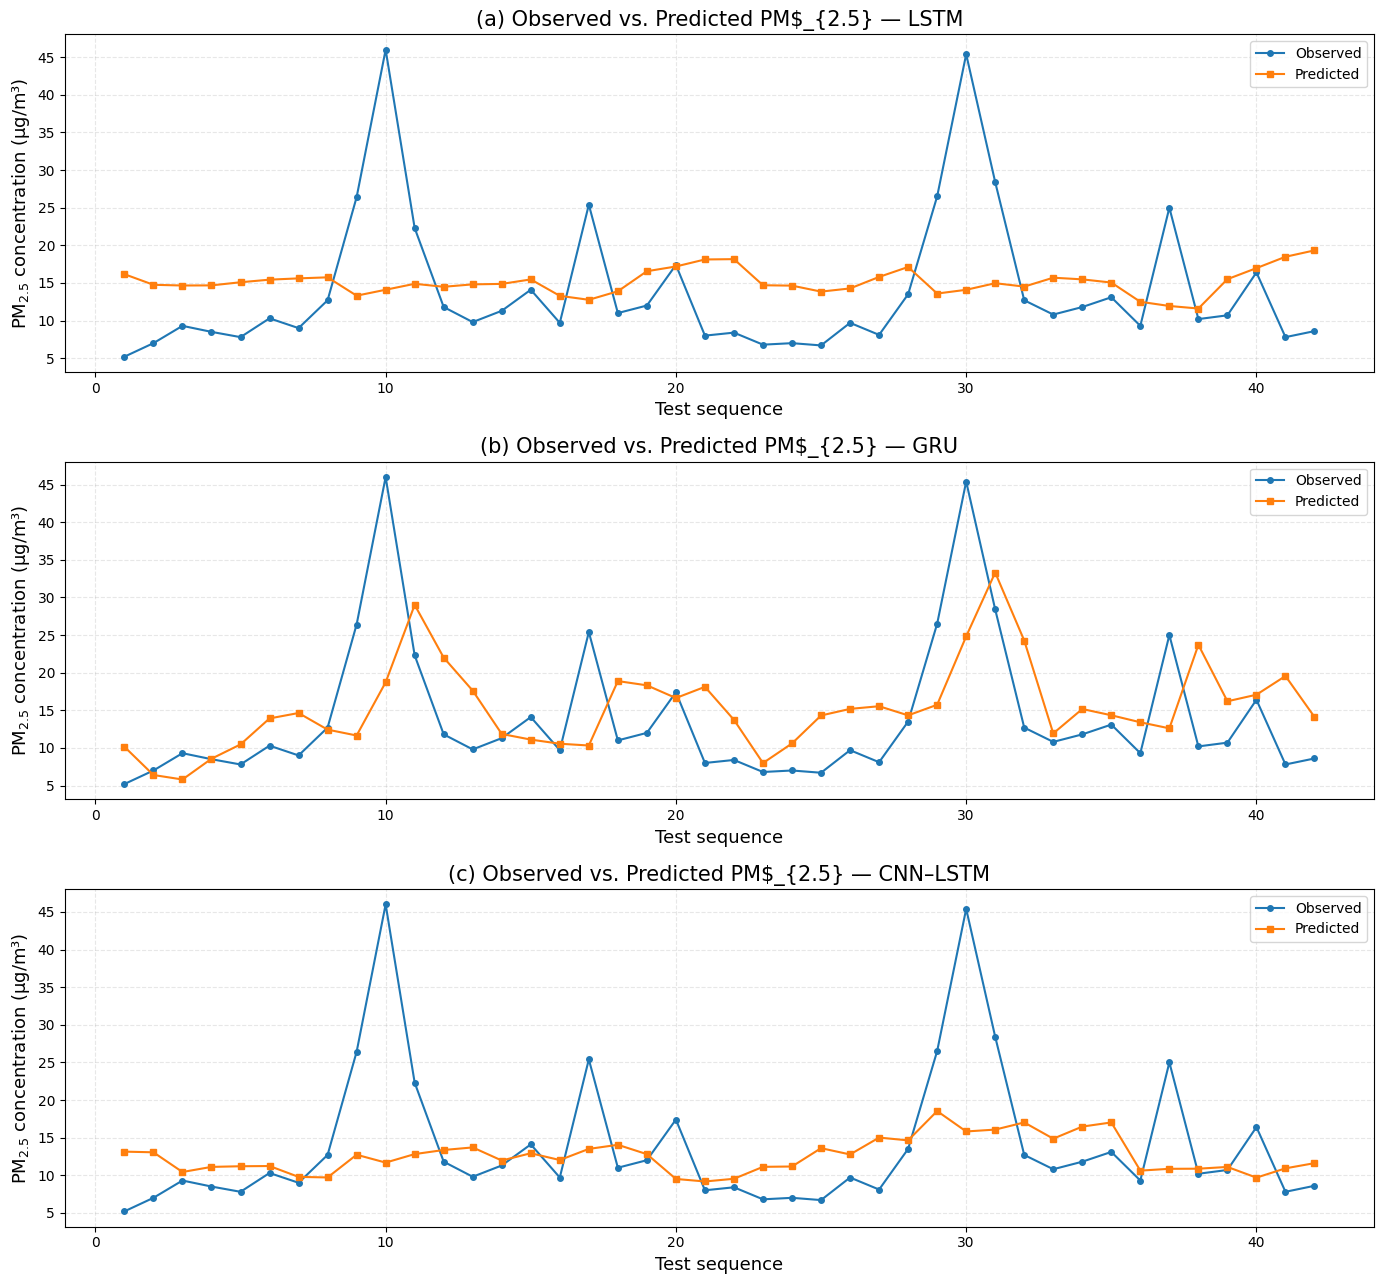

In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# File locations
# ============================================================

base_dir = "."  # Change to the folder containing the files

files = {
    "LSTM": os.path.join(base_dir, "LSTM_Predictions.xlsx"),
    "GRU": os.path.join(base_dir, "GRU_Predictions.xlsx"),
    "CNN–LSTM": os.path.join(base_dir, "CNN_LSTM_Predictions.xlsx")
}

# ============================================================
# Load prediction files
# ============================================================

model_data = {}

for model_name, file_path in files.items():
    data = pd.read_excel(file_path)

    required_columns = {
        "Station",
        "Date",
        "Observed_PM2.5",
        "Predicted_PM2.5"
    }

    missing_columns = required_columns.difference(data.columns)

    if missing_columns:
        raise KeyError(
            f"{model_name} file is missing columns: "
            f"{sorted(missing_columns)}"
        )

    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    data = data.dropna(
        subset=["Date", "Observed_PM2.5", "Predicted_PM2.5"]
    )

    data = data.sort_values(
        ["Station", "Date"]
    ).reset_index(drop=True)

    model_data[model_name] = data

# ============================================================
# Plot settings
# ============================================================

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(14, 13),
    sharex=False
)

subplot_letters = ["(a)", "(b)", "(c)"]

for ax, (model_name, data), letter in zip(
    axes,
    model_data.items(),
    subplot_letters
):
    # Use sequence order because test data contain two stations
    x = range(1, len(data) + 1)

    ax.plot(
        x,
        data["Observed_PM2.5"],
        marker="o",
        markersize=4,
        linewidth=1.5,
        label="Observed"
    )

    ax.plot(
        x,
        data["Predicted_PM2.5"],
        marker="s",
        markersize=4,
        linewidth=1.5,
        label="Predicted"
    )

    ax.set_title(
        f"{letter} Observed vs. Predicted PM$_{{2.5}} — {model_name}"
    )

    ax.set_xlabel("Test sequence")
    ax.set_ylabel("PM$_{2.5}$ concentration (µg/m³)")
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.legend()

plt.tight_layout()

plt.savefig(
    "Observed_vs_Predicted_Deep_Learning_Models.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Observed_vs_Predicted_Deep_Learning_Models.pdf",
    bbox_inches="tight"
)

plt.show()

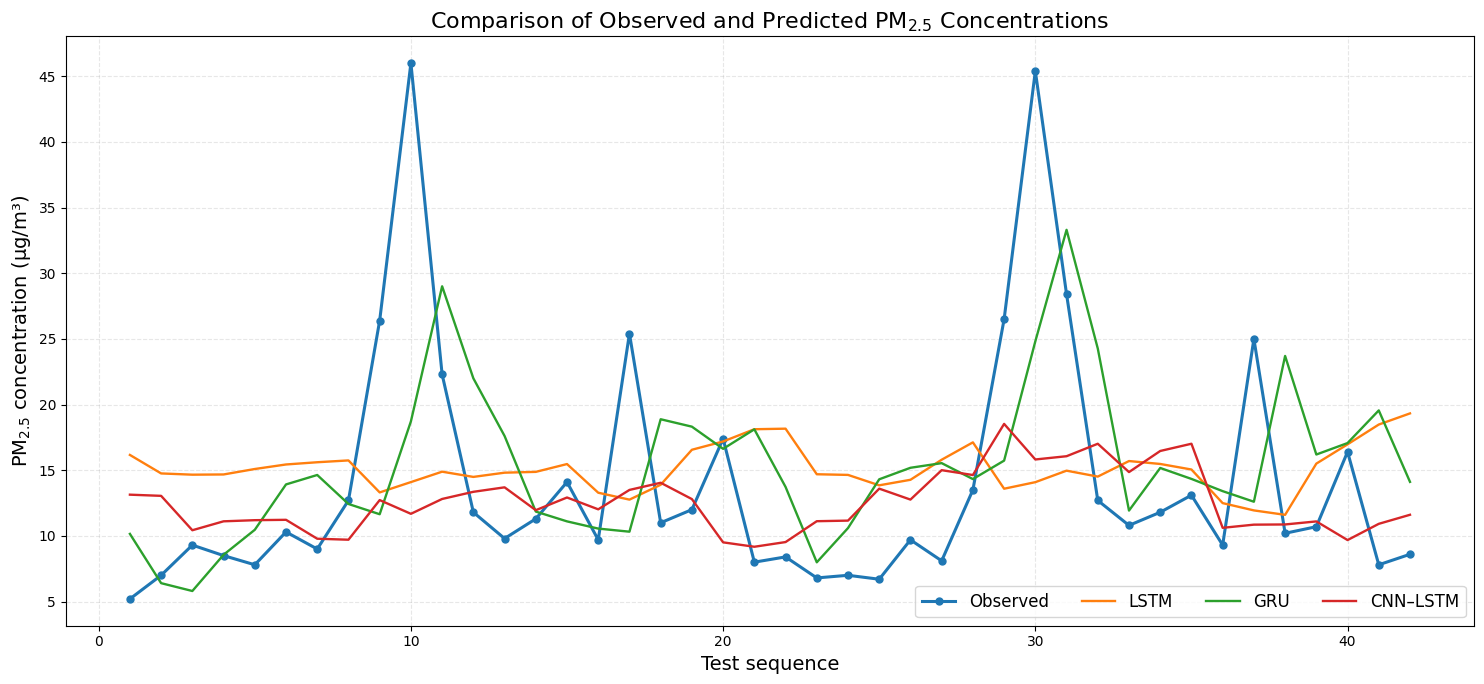

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load files
# ============================================================

lstm_df = pd.read_excel("LSTM_Predictions.xlsx")
gru_df = pd.read_excel("GRU_Predictions.xlsx")
cnn_df = pd.read_excel("CNN_LSTM_Predictions.xlsx")

for data in [lstm_df, gru_df, cnn_df]:
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    data.sort_values(
        ["Station", "Date"],
        inplace=True
    )
    data.reset_index(drop=True, inplace=True)

# ============================================================
# Check that observations are aligned
# ============================================================

if not (
    len(lstm_df) == len(gru_df) == len(cnn_df)
):
    raise ValueError(
        "The prediction files contain different numbers of rows."
    )

alignment_columns = ["Station", "Date"]

if not lstm_df[alignment_columns].equals(
    gru_df[alignment_columns]
):
    raise ValueError(
        "LSTM and GRU predictions are not aligned by station and date."
    )

if not lstm_df[alignment_columns].equals(
    cnn_df[alignment_columns]
):
    raise ValueError(
        "LSTM and CNN–LSTM predictions are not aligned by station and date."
    )

# ============================================================
# Combined plot
# ============================================================

x = range(1, len(lstm_df) + 1)

plt.figure(figsize=(15, 7))

plt.plot(
    x,
    lstm_df["Observed_PM2.5"],
    marker="o",
    markersize=5,
    linewidth=2.2,
    label="Observed"
)

plt.plot(
    x,
    lstm_df["Predicted_PM2.5"],
    linewidth=1.7,
    label="LSTM"
)

plt.plot(
    x,
    gru_df["Predicted_PM2.5"],
    linewidth=1.7,
    label="GRU"
)

plt.plot(
    x,
    cnn_df["Predicted_PM2.5"],
    linewidth=1.7,
    label="CNN–LSTM"
)

plt.xlabel("Test sequence", fontsize=14)
plt.ylabel(
    "PM$_{2.5}$ concentration (µg/m³)",
    fontsize=14
)

plt.title(
    "Comparison of Observed and Predicted PM$_{2.5}$ Concentrations",
    fontsize=16
)

plt.legend(
    fontsize=12,
    ncol=4
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "Deep_Learning_Prediction_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "Deep_Learning_Prediction_Comparison.pdf",
    bbox_inches="tight"
)

plt.show()

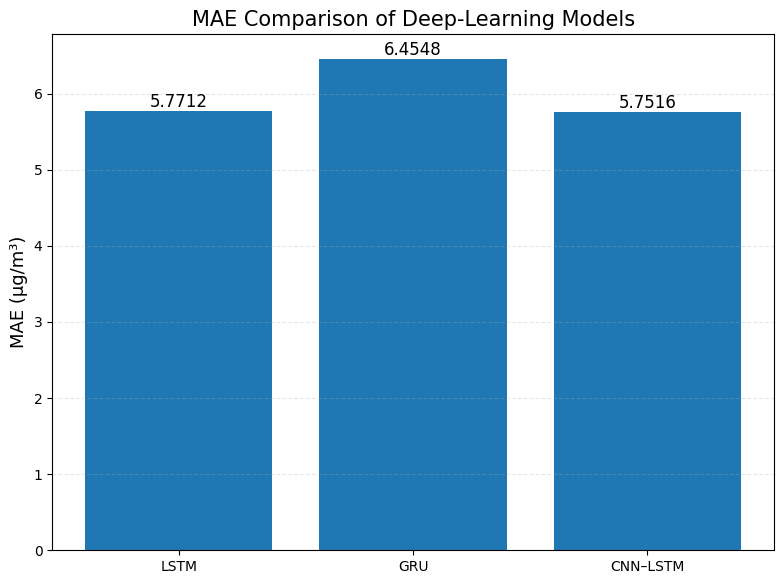

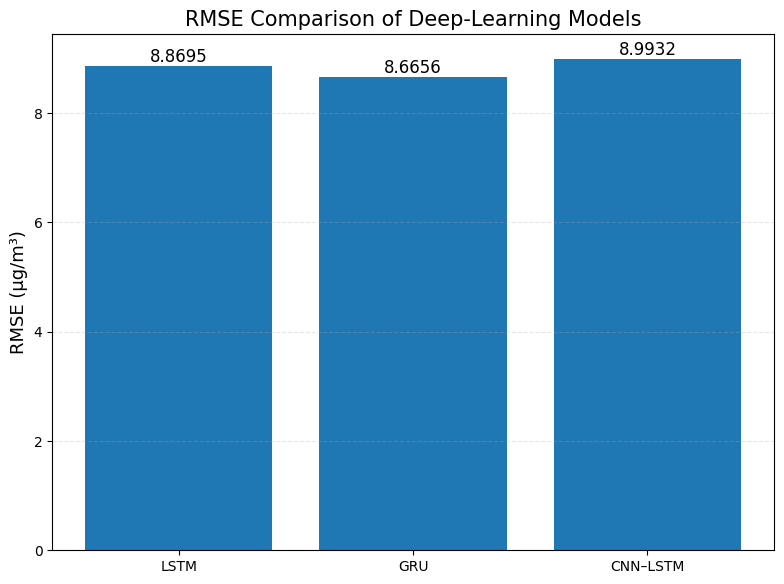

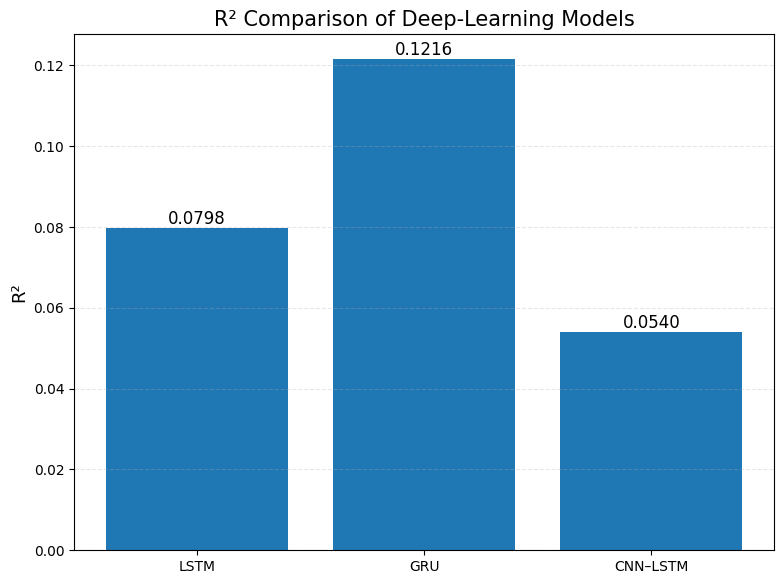

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame({
    "Model": ["LSTM", "GRU", "CNN–LSTM"],
    "MAE": [5.7712, 6.4548, 5.7516],
    "RMSE": [8.8695, 8.6656, 8.9932],
    "R2": [0.0798, 0.1216, 0.0540]
})

# ============================================================
# MAE comparison
# ============================================================

plt.figure(figsize=(8, 6))
bars = plt.bar(
    metrics_df["Model"],
    metrics_df["MAE"]
)

plt.ylabel("MAE (µg/m³)")
plt.title("MAE Comparison of Deep-Learning Models")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, value in zip(bars, metrics_df["MAE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "Deep_Learning_MAE_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# RMSE comparison
# ============================================================

plt.figure(figsize=(8, 6))
bars = plt.bar(
    metrics_df["Model"],
    metrics_df["RMSE"]
)

plt.ylabel("RMSE (µg/m³)")
plt.title("RMSE Comparison of Deep-Learning Models")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, value in zip(bars, metrics_df["RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "Deep_Learning_RMSE_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# ============================================================
# R² comparison
# ============================================================

plt.figure(figsize=(8, 6))
bars = plt.bar(
    metrics_df["Model"],
    metrics_df["R2"]
)

plt.ylabel("R²")
plt.title("R² Comparison of Deep-Learning Models")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar, value in zip(bars, metrics_df["R2"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    "Deep_Learning_R2_Comparison.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# Load training history
# =====================================================

history = pd.read_excel("CNN_LSTM_Training_History.xlsx")

print(history.columns)

Index(['loss', 'val_loss'], dtype='str')


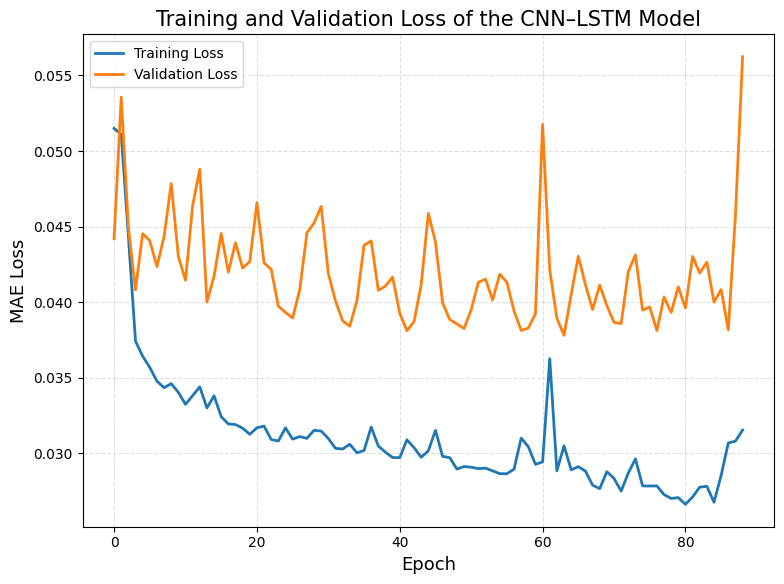

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(
    history["loss"],
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    linewidth=2,
    label="Validation Loss"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("MAE Loss", fontsize=13)
plt.title("Training and Validation Loss of the CNN–LSTM Model", fontsize=15)

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()

plt.savefig(
    "CNN_LSTM_Loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "CNN_LSTM_Loss.pdf",
    bbox_inches="tight"
)

plt.show()

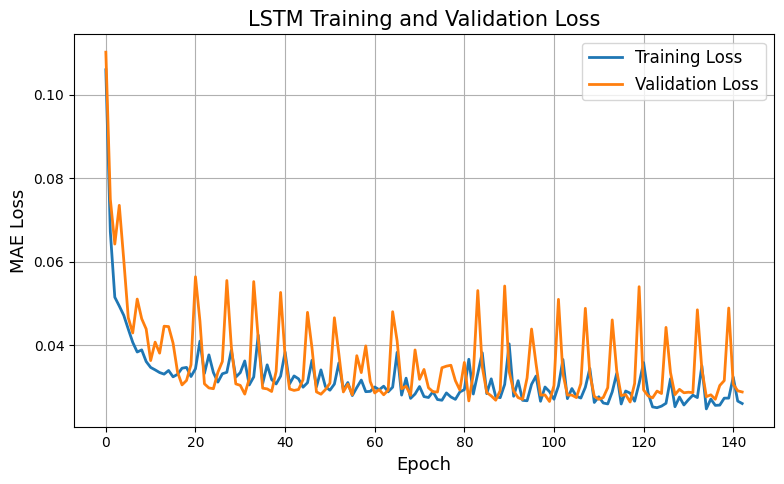

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_2.history['loss'],
         label='Training Loss',
         linewidth=2)

plt.plot(history_2.history['val_loss'],
         label='Validation Loss',
         linewidth=2)

plt.xlabel('Epoch', fontsize=13)
plt.ylabel('MAE Loss', fontsize=13)
plt.title('LSTM Training and Validation Loss', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True)

plt.tight_layout()

# Save figure
plt.savefig("LSTM_Training_Validation_Loss.png", dpi=300)

plt.show()

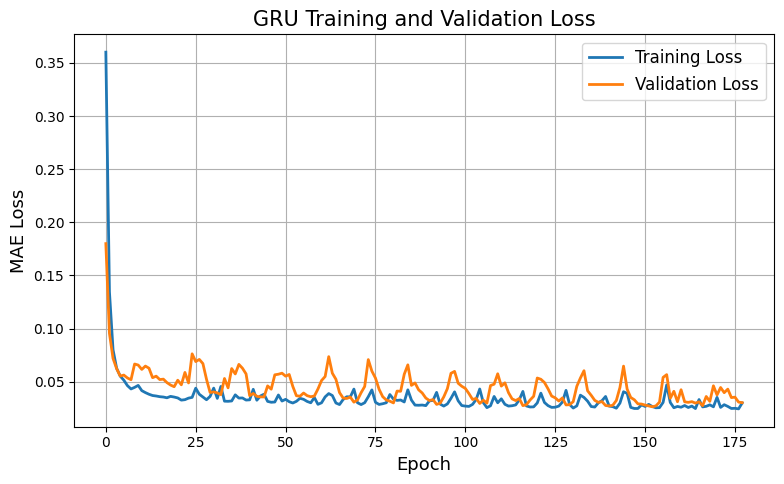

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_gru.history['loss'],
         label='Training Loss',
         linewidth=2)

plt.plot(history_gru.history['val_loss'],
         label='Validation Loss',
         linewidth=2)

plt.xlabel('Epoch', fontsize=13)
plt.ylabel('MAE Loss', fontsize=13)
plt.title('GRU Training and Validation Loss', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True)

plt.tight_layout()

# Save figure
plt.savefig("GRU_Training_Validation_Loss.png", dpi=300)

plt.show()